In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(patchwork)

Warning message:
“程辑包‘dplyr’是用R版本4.2.3 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘tidyr’是用R版本4.2.3 来建造的”


In [2]:
# 读入你刚刚导出的统计表
stat_df <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.4.cNMF_Mono_Macro/4.3.2.Mono_Macro_usage_immu_pheatmap//4.3.2.Mono_Macro_cGEP_usage_cell_patient_stats.csv",
  stringsAsFactors = FALSE
)
stat_df

dataset,cGEP,cell_N_R,cell_N_NR,cell_median_R,cell_median_NR,cell_pvalue,cell_auc,patient_N_R,patient_N_NR,patient_median_R,patient_median_NR,patient_pvalue,patient_auc
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
BreastCancer_Lambrechts,cGEP1,6271,13397,1.496211e-04,1.515744e-05,2.605017e-179,0.6261173,12,28,0.0049144515,0.0020401397,0.65171813,0.5476190
BreastCancer_Lambrechts,cGEP2,6271,13397,1.332475e-04,3.292323e-05,7.592640e-141,0.6115993,12,28,0.0023951485,0.0012568140,0.24748209,0.6190476
BreastCancer_Lambrechts,cGEP3,6271,13397,7.413994e-06,9.590040e-05,7.742203e-281,0.6581727,12,28,0.0044266735,0.0059535140,0.34233265,0.5982143
BreastCancer_Lambrechts,cGEP4,6271,13397,9.275631e-05,3.281042e-05,6.966924e-55,0.5689177,12,28,0.0009423685,0.0009600944,0.84998510,0.5208333
BreastCancer_Lambrechts,cGEP5,6271,13397,6.879030e-05,3.208683e-05,1.550411e-45,0.5625585,12,28,0.0013425692,0.0020003233,0.53088111,0.5654762
BreastCancer_Lambrechts,cGEP6,6271,13397,3.335692e-04,1.192018e-04,1.330665e-74,0.5807169,12,28,0.0058056081,0.0066220741,0.69428755,0.5416667
BreastCancer_Lambrechts,cGEP7,6271,13397,4.354150e-04,1.585732e-04,2.764351e-73,0.5799825,12,28,0.0047481466,0.0059566874,0.89583080,0.5148810
BreastCancer_Lambrechts,cGEP8,6271,13397,6.540734e-05,8.439909e-05,5.650266e-05,0.5177871,12,28,0.0032388609,0.0032517060,0.37310465,0.5922619
BreastCancer_Lambrechts,cGEP9,6271,13397,1.169695e-04,3.541287e-05,1.446353e-60,0.5725139,12,28,0.0024366554,0.0025012845,0.82723626,0.4761905


In [3]:
# 先画病人的汇总热图。
# 只保留有 patient_auc 的
heat_df <- stat_df %>%
  select(dataset, cGEP, patient_N_R, patient_N_NR, patient_auc) %>%
  filter(!is.na(patient_auc))
colnames(heat_df)[2] = 'pathway'
colnames(heat_df)[3] = 'patient_R'
colnames(heat_df)[4] = 'patient_NR'

In [4]:
# 排序
# 1.dataset 按名字
heat_df$dataset <- factor(
  heat_df$dataset,
  levels = unique(heat_df$dataset))

# 2. pathway , 1 到 70 的正确名称列表
levels_order <- paste0("cGEP", 1:77)

# 将 pathway 转换为因子，并指定 levels 顺序
heat_df$pathway <- factor(heat_df$pathway, levels = levels_order)
heat_df

dataset,pathway,patient_R,patient_NR,patient_auc
<fct>,<fct>,<int>,<int>,<dbl>
BreastCancer_Lambrechts,cGEP1,12,28,0.5476190
BreastCancer_Lambrechts,cGEP2,12,28,0.6190476
BreastCancer_Lambrechts,cGEP3,12,28,0.5982143
BreastCancer_Lambrechts,cGEP4,12,28,0.5208333
BreastCancer_Lambrechts,cGEP5,12,28,0.5654762
BreastCancer_Lambrechts,cGEP6,12,28,0.5416667
BreastCancer_Lambrechts,cGEP7,12,28,0.5148810
BreastCancer_Lambrechts,cGEP8,12,28,0.5922619
BreastCancer_Lambrechts,cGEP9,12,28,0.4761905


In [5]:
# --- 1. 数据过滤与准备 ---
# 过滤掉不需要的数据集
exclude_datasets <- c("GSE203115","HCC_YeYouqiong",
                      "RenalCarcinoma","GSE123813_BCC")
heat_df_filt <- heat_df[!(heat_df$dataset %in% exclude_datasets), ]
heat_df_filt

,dataset,pathway,patient_R,patient_NR,patient_auc
,<fct>,<fct>,<int>,<int>,<dbl>
1,BreastCancer_Lambrechts,cGEP1,12,28,0.5476190
2,BreastCancer_Lambrechts,cGEP2,12,28,0.6190476
3,BreastCancer_Lambrechts,cGEP3,12,28,0.5982143
4,BreastCancer_Lambrechts,cGEP4,12,28,0.5208333
5,BreastCancer_Lambrechts,cGEP5,12,28,0.5654762
6,BreastCancer_Lambrechts,cGEP6,12,28,0.5416667
7,BreastCancer_Lambrechts,cGEP7,12,28,0.5148810
8,BreastCancer_Lambrechts,cGEP8,12,28,0.5922619
9,BreastCancer_Lambrechts,cGEP9,12,28,0.4761905


In [6]:
Macro_cGEP <- read.csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.4.cNMF_Mono_Macro/3.1.Macro_GEP_Anno/3.3.Macro_cGEP_Anno_Complete_With_Genes.csv",
  stringsAsFactors = FALSE,
  check.names = FALSE)
Macro_cGEP$cGEP_Cluster <- factor(Macro_cGEP$cGEP_Cluster, levels = paste0("cGEP", 1:77))
Macro_cGEP$Display_Label <- paste0(Macro_cGEP$cGEP_Cluster, ": ", Macro_cGEP$cGEP_Anno_Name)
Macro_cGEP <- Macro_cGEP[order(Macro_cGEP$cGEP_Cluster), ]
Macro_cGEP

,cGEP_Cluster,cGEP_Anno_Name,Category,cGEP_signature,Display_Label
,<fct>,<chr>,<chr>,<chr>,<chr>
1,cGEP1,Macro_M1_Invasive,Functional,"IL1B,PLAUR,C15ORF48,SRGN,SOD2,EREG,NAMPT,BCL2A1,CXCL8,CXCL2,G0S2,NFKBIA,BTG1,SAMSN1,AQP9,CXCL3,FTH1,TIMP1,OLR1,THBS1,PNRC1,CD44,IER3,NLRP3,C5AR1,CCL20,SAT1,TNFAIP3,SLC2A3,PTGS2",cGEP1: Macro_M1_Invasive
2,cGEP2,Stress_HeatShock,Artifact,"HSP90AA1,HSPA1A,HSPB1,HSPA1B,DNAJB1,HSPE1,IER5,ZFAND2A,HSPD1,HSPH1,HSPA6,DUSP1,RHOB,BAG3,DNAJB4,RGS2,UBC,MTRNR2L2,HSP90AB1,AP000769.1,ND3,CLK1,KLF2,DNAJA4,UBB,DNAJA1,CACYBP,RPS4Y1,SH3BGRL3,SHISAL2A",cGEP2: Stress_HeatShock
3,cGEP3,Tumor_Neura_Progenitor,Doublet,"FABP7,ZIC5,RP11-408N14.1,RP1-56K13.2,FGG,SPRR1B,PRSS57,DPP10,HOXD10,RPS18,RPS6,SFTPA1,SPRR2D,SFTPA2,AP001171.1,RPS23,RPS4X,RPL3,RPS3,POU3F3,RPS12,CLDN2,RPLP0,RPS5,NPM1,FGB,RPS2,RPS7,RPL10A,RP11-817J15.2",cGEP3: Tumor_Neura_Progenitor
4,cGEP4,Stress_HeatShock,Artifact,"DNAJB1,HSPA1B,HSPA1A,HSP90AA1,BAG3,HSPB1,HSPH1,HSP90AA2P,HSPD1,HSPA6,UBC,HSP90AB1,DNAJB1P1,JUN,DNAJA1,ZFAND2A,HSPE1,HSPA8,IER5,HSP90AA4P,DUSP1,DNAJA4,ZSCAN12P1,PCYT1B,PPP1R15A,ATF3,NR4A1,RGS2,UBB,HSPA7",cGEP4: Stress_HeatShock
5,cGEP5,Mono_CD14_FCN1,Lineage,"S100A9,S100A8,LYZ,S100A12,VCAN,GAPDH,S100A6,AC020656.1,FCN1,TSPO,PLBD1,VIM,CSTA,METTL9,SELL,ATP5MPL,S100A4,TKT,LGALS1,RF00012,CD36,S100A10,RP11-1143G9.4,MGST1,RETN,SERPINB1,CES1,ATP5F1E,TALDO1,CDA",cGEP5: Mono_CD14_FCN1
6,cGEP6,Mono_Classical_Trafficking,Lineage,"MTCO1P53,S100A9,RP11-240E2.2,S100A8,LYZ,FCN1,VCAN,S100A12,Metazoa-SRP,RP5-857K21.11,AC138744.2,RP4-635A23.6,AC016739.2,SELL,MNDA,S100A6,TKT,LA16C-306A4.2,RP11-417L19.5,4h.2,RP3-417G15.1,PLBD1,CSTA,CTD-2649C14.2,RP11-362F19.2,RP5-857K21.7,CTSS,TSPO,S100A4,CTB-181H17.1",cGEP6: Mono_Classical_Trafficking
7,cGEP7,Mono_CD16,Lineage,"AC079325.2,FCGR3A,LST1,C19ORF38,IFITM2,RPS19,RHOC,CNTN5,CDKN1C,C10ORF54,SMIM25,IFITM3,AC104809.2,AIF1,NDNF,C15ORF39,NAP1L1,AC104809.4,LINC01272,MS4A7,LOC100130520,TCF7L2,LINC02334,RP5-857K21.11,SERPINA1,COTL1,FCER1G,CD79B,LOC101928037,LOC100507639",cGEP7: Mono_CD16
8,cGEP8,pDC,Lineage,"GZMB,CLEC4C,LILRA4,CLIC3,SMPD3,PACSIN1,LRRC26,TSPAN13,PTCRA,MZB1,ITM2C,IGJ,IRF7,TLR9,JCHAIN,RP11-73G16.2,IRF4,SCT,FAM129C,LOC101928123,C12orf75,TCL1A,PPP1R14B,CXCR3,DERL3,SPIB,LOC101929219,RP1-302G2.5,TCF4,MAP1A",cGEP8: pDC
9,cGEP9,Macro_M2_Foam,Lineage,"ACP5,LGALS3,CALR,CD63,PLA2G7,FTL,CTSB,CTSD,TGFBI,PRDX1,FPR3,CAPG,CTSL,S100A11,FABP5,NPC2,YBX1,PSAP,PMP22,FABP5P7,IFI30,HSP90B1,APOE,AC026366.1,PPIB,ATP6V1F,ANXA2,PCOLCE2,HLA-DQA2,HLA-DRB5",cGEP9: Macro_M2_Foam


In [7]:
library(dplyr)
immudataInfo <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.2.免疫治疗dataset.csv",
  stringsAsFactors = FALSE)

# 1. 预处理 immudataInfo，生成对应的标签格式
# 格式为：Cancer_Dataset(Treatment)
info_mapping <- immudataInfo %>%
  mutate(new_label = paste0(Cancer, "_", Dataset, "(", Treatment, ")")) %>%
  select(Dataset, new_label)

# 2. 将新标签合并到 heat_df_filt 中
# 使用 left_join 根据 Dataset 进行匹配
heat_df_filt2 <- heat_df_filt %>%
  left_join(info_mapping, by = c("dataset" = "Dataset")) %>%
  mutate(dataset = ifelse(!is.na(new_label), new_label, dataset)) %>%
  select(-new_label) # 移除临时列


In [8]:
library(dplyr)
library(ggplot2)
library(patchwork)

# =========================================================
# 函数：绘制 Macro_cGEP cGEP 热图 + 可选注释条过滤
# =========================================================
plot_Macro_heatmap <- function(
  heat_df,           # 主热图数据框，列：dataset, pathway, patient_auc
  anno_df,           # 注释数据框，列：cGEP_Cluster, cGEP_Anno_Name, Category
  keep_categories,   # 需要保留的 Category 向量，例如 c("Function","Artifact")
  output_file,       # 保存 PDF 路径
  width = 12,
  height = 16,
  fill_midpoint = 0.6
) {
  
  # ---------------------------
  # 1️⃣ 排序 cGEP
  # ---------------------------
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)
  
  # ---------------------------
  # 2️⃣ 主热图 factor
  # ---------------------------
  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)
  
  # ---------------------------
  # 3️⃣ 注释条 factor & 过滤
  # ---------------------------
  # 关键修改：只保留热图中存在的cGEP_Cluster
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%  # 先过滤热图中存在的Cluster
    filter(Category %in% keep_categories) %>%   # 再过滤需要的类别
    arrange(match(cGEP_Cluster, sorted_cgeps))  # 按照热图顺序排序
  
  # 更新sorted_cgeps，只包含注释条中存在的
  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))
  
  # 设置因子水平（使用过滤后的顺序）
  anno_df$cGEP_Cluster <- factor(anno_df$cGEP_Cluster, levels = sorted_cgeps_filtered)
  
  # labels 对齐
  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster
  
  # ---------------------------
  # 4️⃣ 主热图（需要过滤以匹配注释条）
  # ---------------------------
  # 如果注释条过滤后为空，则不绘制注释条
  if (nrow(anno_df) == 0) {
    warning("过滤后注释条为空，将只绘制热图")
    heat_df_filtered <- heat_df
  } else {
    # 只保留注释条中存在的pathway
    heat_df_filtered <- heat_df %>%
      filter(pathway %in% sorted_cgeps_filtered)
    
    # 重新设置因子水平以匹配注释条顺序
    heat_df_filtered$pathway <- factor(heat_df_filtered$pathway, levels = sorted_cgeps_filtered)
  }
  
  p_main <- ggplot(
    heat_df_filtered,
    aes(x = dataset, y = pathway, fill = patient_auc)
  ) +
    geom_tile(color = "white", linewidth = 0.2) +
    scale_fill_gradient2(
      low = "#2166AC", mid = "white", high = "#B2182B",
      midpoint = fill_midpoint, name = "AUC"
    ) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10, color = "black"),
      axis.text.y = element_text(size = 8, color = "black"),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(t = 10, r = 0, b = 60, l = 30, unit = "pt")
    )
  
  # ---------------------------
  # 5️⃣ 注释条（仅在存在数据时绘制）
  # ---------------------------
  if (nrow(anno_df) > 0) {
    fill_values <- setNames(
      c("#4daf4a", "#999999", "#377eb8", "#984ea3")[match(keep_categories, c("Functional","Artifact","Lineage","Doublet"))],
      keep_categories
    )
    
    p_side <- ggplot(
      anno_df,
      aes(x = "Class", y = cGEP_Cluster, fill = Category)
    ) +
      geom_tile(color = "white", linewidth = 0.2) +
      scale_fill_manual(values = fill_values, name = "Class") +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_discrete(
        expand = c(0, 0), 
        position = "right", 
        labels = anno_labels,
        limits = levels(anno_df$cGEP_Cluster)  # 确保与热图y轴完全一致
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, size = 10, face = "bold.italic", color = "black"),
        axis.text.y = element_text(size = 8, color = "black"),
        panel.grid = element_blank(),
        axis.title = element_blank(),
        plot.margin = margin(t = 10, r = 100, b = 60, l = 0, unit = "pt")
      )
    
    # ---------------------------
    # 6️⃣ 拼接 + 保存
    # ---------------------------
    final_plot <- (p_main | p_side) +
      plot_layout(widths = c(5, 0.3), guides = "collect") &
      theme(panel.spacing = unit(0, "pt"))
  } else {
    # 如果注释条为空，只绘制热图
    final_plot <- p_main
  }
  
  ggsave(output_file, final_plot, width = width, height = height, limitsize = FALSE)
  
  return(final_plot)
}

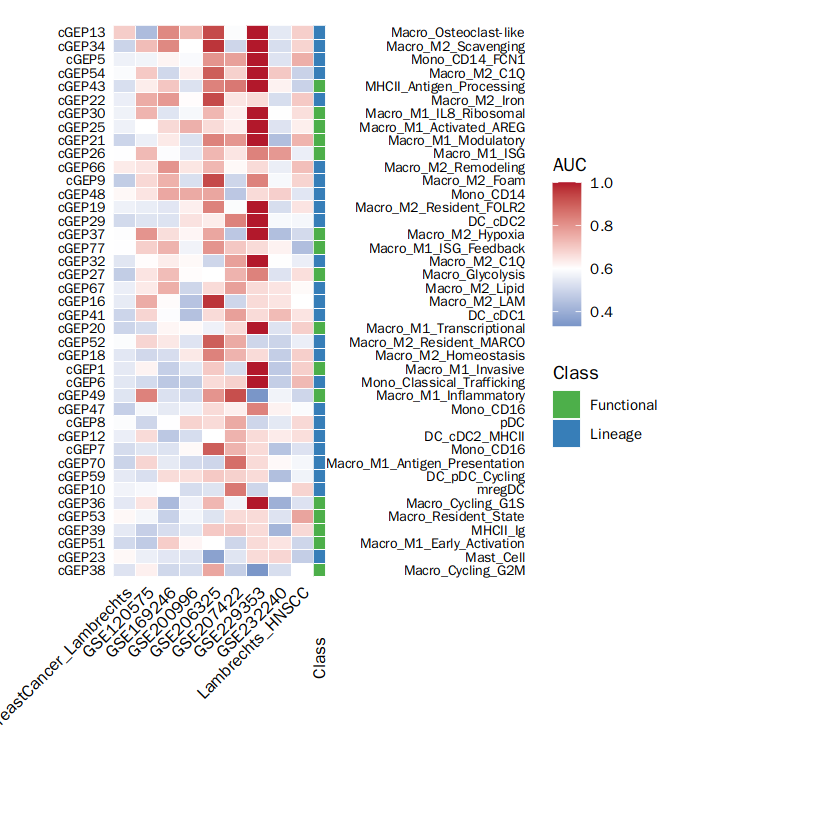

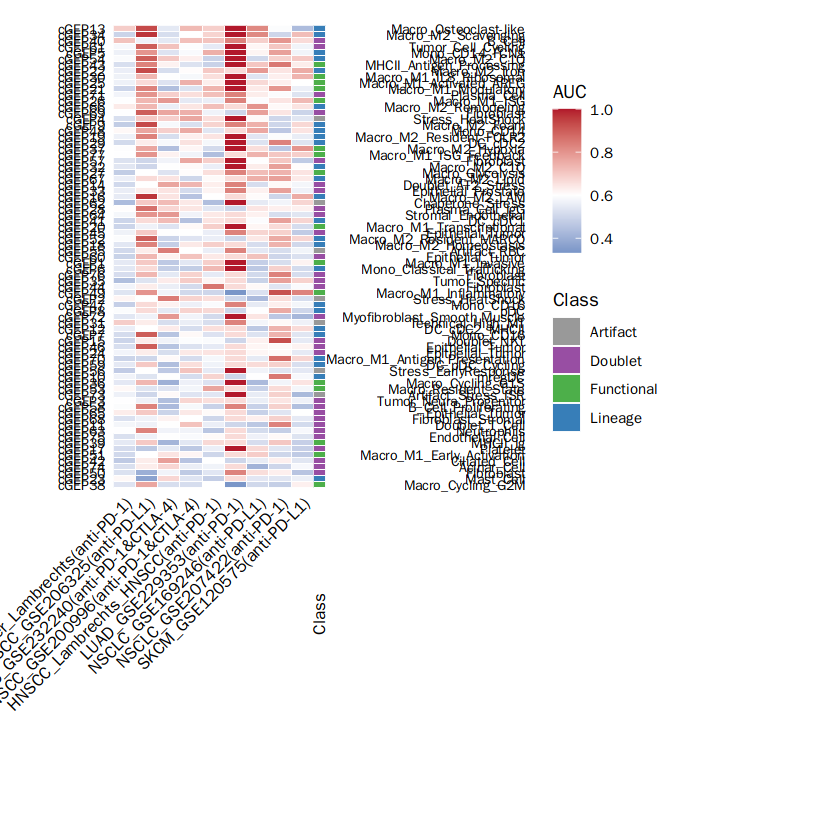

In [16]:
# 只保留 Function 和 Artifact
plot_Macro_heatmap(
  heat_df = heat_df_filt,
  anno_df = Macro_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Mono_Macro_usage_immu_pheatmap/4.3.2.Macrp_GEP77_usage_heatmap_filtered_sorted_mean.pdf",
  width = 12,
  height = 16
)

# 都留
plot_Macro_heatmap(
  heat_df = heat_df_filt,
  anno_df = Macro_cGEP,
  keep_categories = c("Functional","Artifact","Lineage","Doublet"),
  output_file = "./4.3.2.Mono_Macro_usage_immu_pheatmap/4.3.2.Macrp_GEP77_usage_heatmap_all_sorted_mean.pdf",
  width = 12,
  height = 16
)


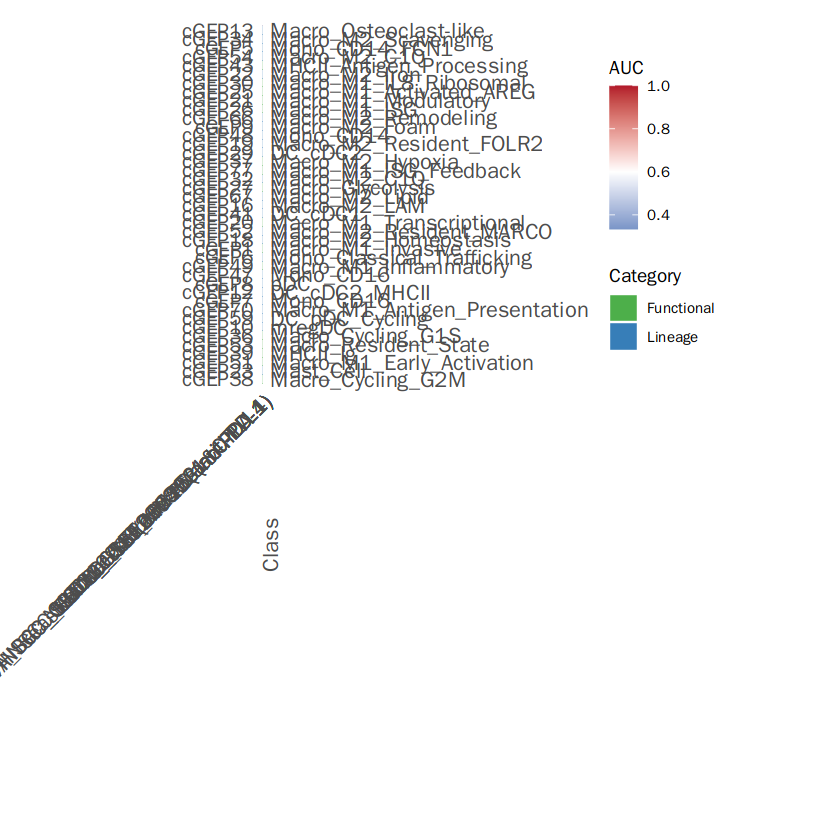

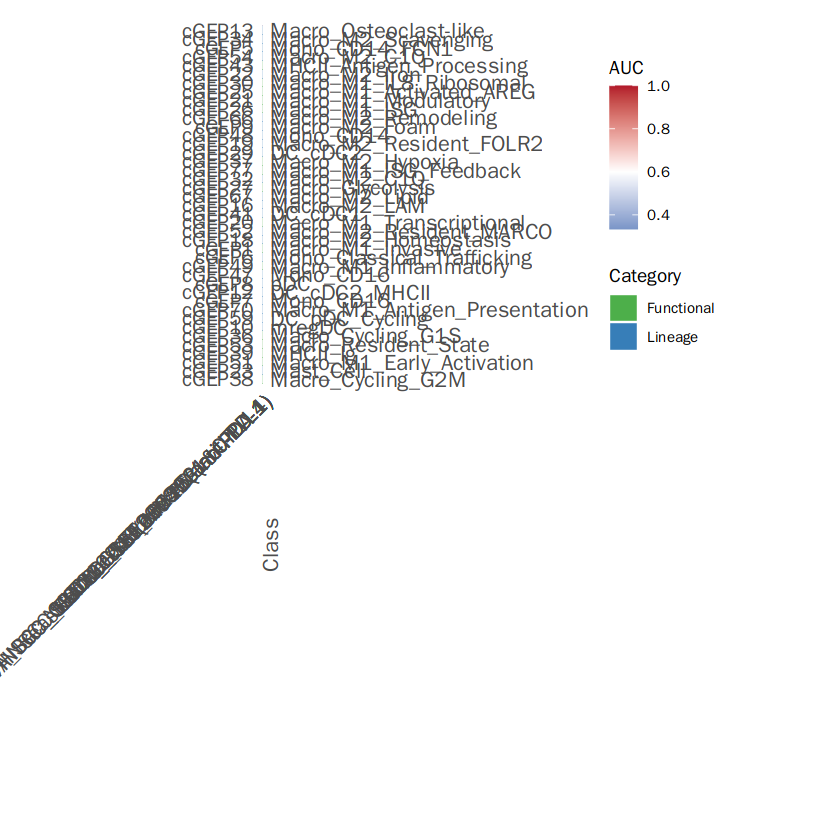

In [22]:
library(dplyr)
library(ggplot2)
library(patchwork)

plot_heatmap <- function(
  heat_df,
  anno_df,
  keep_categories,
  output_file,
  cell_width,
  cell_height,
  fill_midpoint = 0.6
){

  # 1️⃣ 排序
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)

  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)

  # 2️⃣ annotation过滤
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%
    filter(Category %in% keep_categories) %>%
    arrange(match(cGEP_Cluster, sorted_cgeps))

  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))

  anno_df$cGEP_Cluster <- factor(
    anno_df$cGEP_Cluster,
    levels = sorted_cgeps_filtered
  )

  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster

  heat_df_filtered <- heat_df %>%
    filter(pathway %in% sorted_cgeps_filtered)

  heat_df_filtered$pathway <- factor(
    heat_df_filtered$pathway,
    levels = sorted_cgeps_filtered
  )

  # 3️⃣ 自动计算图尺寸
  n_row <- length(sorted_cgeps_filtered)
  n_col <- length(unique(heat_df_filtered$dataset))

  height <- n_row * cell_height + 4
  width  <- n_col * cell_width + 6

  # 4️⃣ 主热图
  p_main <- ggplot(
    heat_df_filtered,
    aes(dataset, pathway, fill = patient_auc)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_gradient2(
      low="#2166AC",
      mid="white",
      high="#B2182B",
      midpoint=fill_midpoint,
      name="AUC"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(expand=c(0,0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=45,
        hjust=1,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=12,
        face="bold"
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(10,0,80,140)
    )

  # 5️⃣ annotation
  fill_values <- setNames(
    c("#4daf4a","#377eb8","#999999","#984ea3")[
      match(keep_categories,
      c("Functional","Lineage","Artifact","Doublet"))
    ],
    keep_categories
  )

  p_side <- ggplot(
    anno_df,
    aes("Class", cGEP_Cluster, fill = Category)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(values = fill_values) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(
      expand=c(0,0),
      position="right",
      labels=anno_labels
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=90,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=13,
        face="bold",
        hjust=0
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      plot.margin = margin(10,100,40,0)
    )

  # 6️⃣ 拼接
  final_plot <- (p_main | p_side) +
    plot_layout(widths=c(5,0.35), guides="collect") &
    theme(panel.spacing = unit(0,"pt"))

  # 7️⃣ 保存
  ggsave(
    output_file,
    final_plot,
    width = width,
    height = height,
    dpi = 300,
    limitsize = FALSE
  )

  return(final_plot)
}
# 只保留 Function 和 Artifact
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = Macro_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Mono_Macro_usage_immu_pheatmap/4.3.2.Macrp_GEP77_usage_paper-v0417.png",
  cell_width = 0.5,
  cell_height = 0.25
)
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = Macro_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Mono_Macro_usage_immu_pheatmap/4.3.2.Macrp_GEP77_usage_paper-v0417.pdf",
  cell_width = 0.5,
  cell_height = 0.25
)